In [1]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import igl
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import map_coordinates
from skimage.measure import marching_cubes

from seamless import Parameterizer
from seamless.cartography import eval_surface
from seamless.cartography.projection import _orient_outward
from seamless.pipeline import _binarize_segmentation
from seamless.utils.ome_zarr import OMEZarrDataset

DEFAULT_STORE = "../../Position_10.ome.zarr"  # relative default; override via the env var below
STORE = Path(os.environ.get("SEAMLESS_OME_ZARR_STORE", DEFAULT_STORE))

TOPOLOGY = "cylinder"          # closed, roughly spherical embryo surface
LABEL_NAME = "embryo"        # existing precomputed segmentation under labels/<name>/
LABEL_LEVEL = 1              # coarse -- fast marching_cubes, no accuracy loss (see above)
INTENSITY_LEVEL = 0          # full resolution -- what we actually want to project
UV_RES = 512
NUM_TARGET_POINTS = 20_000
T = 15
NUM_CHARTS = 3   # pole_pole_band below requires exactly 3 charts (1 band + 2 poles)
timings = {}


class _Timed:
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        timings[self.name] = time.perf_counter() - self.t0
        print(f"[{self.name}] {timings[self.name]:.2f}s")


def timed(name):
    return _Timed(name)

In [2]:
with timed("open dataset"):
    ds = OMEZarrDataset(STORE)

print(f"timepoints: {ds.n_timepoints}, channels: {ds.n_channels}")
print(f"levels: {[(lv.path, lv.shape, lv.voxel_size_um) for lv in ds.levels]}")
print(f"available labels: {ds.label_names}")

[open dataset] 0.00s
timepoints: 132, channels: 1
levels: [('0', (132, 1, 300, 2291, 2303), (1.0, 0.26, 0.26)), ('1', (132, 1, 150, 1145, 1151), (2.0, 0.52, 0.52)), ('2', (132, 1, 150, 572, 575), (2.0, 1.04, 1.04)), ('3', (132, 1, 150, 286, 287), (2.0, 2.08, 2.08)), ('4', (132, 1, 150, 143, 143), (2.0, 4.16, 4.16))]
available labels: ['embryo']


In [3]:
with timed("t=0 segmentation-to-mapping (label_level={})".format(LABEL_LEVEL)):
    p0 = Parameterizer.from_ome_zarr(
        STORE, TOPOLOGY, t=T, level=INTENSITY_LEVEL,
        label_name=LABEL_NAME, label_level=LABEL_LEVEL,
        num_target_points=NUM_TARGET_POINTS, num_charts=NUM_CHARTS
    )

print(f"t=0 surface points: {p0._full_points.shape[0]}")
print(f"device: {p0.device}")

[t=0 segmentation-to-mapping (label_level=1)] 5.17s
t=0 surface points: 20000
device: cuda


In [4]:
# Switched from the paper-mode/no-warm-start ablation to the pole/pole/band analytic
# warm-start (seamless/cartography/train.py::_pole_pole_band_seed): chart 0 = the
# equatorial band (cylindrical unwrap), charts 1/2 = the two poles (azimuthal disk
# in each chart's unit square) -- the same 2-poles + 1-band split Blender tissue
# cartography uses on an ellipsoid, instead of uniform azimuthal wedges. Requires
# NUM_CHARTS=3 (set above) and use_warm_start=True (chart_layout is a warm-start
# seed choice -- it's ignored entirely in paper mode/use_warm_start=False).
with timed("t=0 train (cold start)"):
    model0 = p0.train(iterations=1, verbose=True, use_warm_start=True,
                      lr=1e-4, sigma_lr=0.1, hidden_dim=256, num_layers=8,
                      chart_layout="pole_pole_band", pole_fraction=0.15,
                      pole_profile="equidistant")

uv_map0 = p0.get_uv_map()
print(f"UV map: {uv_map0.shape}")

────────────────── Phase 5 - Nuvo Parameterisation ───────────────────
  num_charts=3  topology=cylinder  pe_degree=2
  curriculum: Phase A (warm-up) → Phase B (geometry) → Phase C (full Nuvo)

  [warm-start] Pre-training on supervised 3-chart cylinder UV (chart_layout='pole_pole_band') …
  [warm-start] iter  100/300  total=0.555112
  [warm-start] iter  200/300  total=0.553235
  [warm-start] iter  300/300  total=0.553795
  [warm-start] Done.

 iter  phase     total     conf    strch    clust     surf      323      232       σ
──────────────────────────────────────────────────────────────────────
    1      C    2.1021   0.4580  16.9980   0.1217   0.0008   0.0004   0.0172  1.0000
[t=0 train (cold start)] 16.95s
UV map: (20000, 2)


In [5]:
np.bincount(p0.chart_ids) 

array([13698,  3147,  3155])

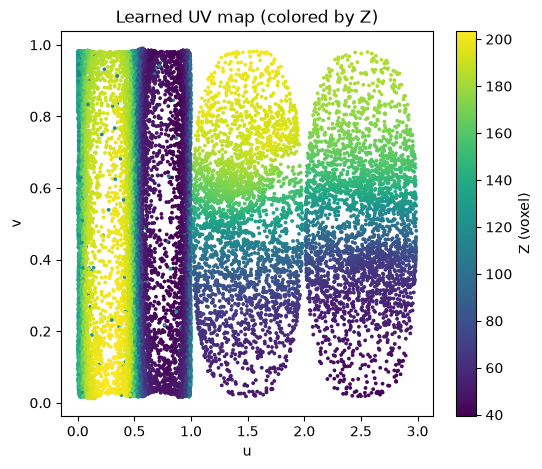

In [6]:
pts = p0.points_voxel.numpy()         # surface points in voxel space
uv_map = p0.get_uv_map()  
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(uv_map[:, 0], uv_map[:, 1], c=pts[:, 0], s=3, cmap='viridis')
ax.set(xlabel='u', ylabel='v', title='Learned UV map (colored by Z)')
fig.colorbar(sc, ax=ax, label='Z (voxel)')
plt.show()

In [7]:
# Caveat for pole_pole_band: the u=0/u=1 "seam gap" printed below is only a
# meaningful cut for chart 0 (the band, cylindrical unwrap -- same seam convention
# as before). Charts 1/2 (poles) are azimuthal disks inscribed in their unit
# square: their real boundary is the disk edge (all azimuths at rho=1), not a
# fixed u value, and most of the u=0/u=1 edges fall in the square's corners
# outside the disk where there's no training support at all. Expect the pole
# charts' printed "gap" to look large/noisy -- that's an artifact of applying a
# wedge-shaped diagnostic to a disk-shaped chart, not a sign the pole charts are
# badly trained.
def plot_uv_seam_3d(param, voxel_size_um, translation, n_seam_samples=400,
                     title="UV seam on surface (physical space)"):
    """Interactive 3D Plotly view of a trained Parameterizer's surface, with the UV
    seam traced directly from the network's UV->3D mapping (not inferred from the
    training point cloud's incidental density near the cut).

    Args:
        param: A trained `Parameterizer` (`.train()` already called).
        voxel_size_um: (z, y, x) microns per voxel for the level `param.points_voxel` is in.
        translation:   (z, y, x) physical offset (µm) for that same level.
        n_seam_samples: Number of points sampled along each chart's seam curve.
    """
    scale = np.asarray(voxel_size_um, dtype=np.float64)
    trans = np.asarray(translation, dtype=np.float64)

    def to_um(pts_voxel):
        return pts_voxel * scale + trans  # (Z, Y, X) order preserved

    pts = param.points_voxel.numpy()
    uv_map = param.get_uv_map()
    chart_ids = param.chart_ids
    pts_um = to_um(pts)

    u_local = uv_map[:, 0] - chart_ids
    d_seam = np.minimum(u_local, 1.0 - u_local)   # 0 at the seam, 0.5 antipodal to it

    # pts_um columns are (Z, Y, X); plot as (X, Y, Z) for a conventional right-handed view
    x, y, z = pts_um[:, 2], pts_um[:, 1], pts_um[:, 0]

    main_trace = go.Scatter3d(
        x=x, y=y, z=z, mode="markers", name="surface (dist-to-seam)",
        marker=dict(
            size=2, color=d_seam, colorscale="Viridis", showscale=True,
            colorbar=dict(title="dist to seam<br>(local u)"),
        ),
    )

    # Trace the seam curve itself: query the trained model at u=0 and u=1 (the two
    # edges of each chart's UV square -- the same physical cut) across the full v
    # range, per chart. This is the ground truth for "where is the seam", independent
    # of how the training point cloud happened to sample near it.
    model = param.get_model()
    pts_mean = param.pts_mean.numpy()
    pts_std = float(param.pts_std)
    v_line = np.linspace(0.0, 1.0, n_seam_samples, dtype=np.float32)
    edge_style = {0.0: dict(color="red", dash=None), 1.0: dict(color="orange", dash="dash")}

    seam_traces = []
    for chart in np.unique(chart_ids):
        edge_um = {}
        for u_edge in edge_style:
            uv_edge = np.stack([np.full_like(v_line, u_edge), v_line], axis=1)
            xyz_norm_edge = eval_surface(model, uv_edge, chart_idx=int(chart), device=param.device)
            edge_um[u_edge] = to_um(xyz_norm_edge * pts_std + pts_mean)

        # Since u=0 and u=1 are the *same* physical cut, a perfectly cycle-consistent
        # model would place them at identical 3D positions -- any gap is a direct,
        # measurable sign of how well the NuvoMLP's cut is actually "glued".
        gap = np.linalg.norm(edge_um[0.0] - edge_um[1.0], axis=1)
        print(f"[{title}] chart {chart}: NuVo seam gap between u=0/u=1 curves -- "
              f"mean {gap.mean():.1f} um, max {gap.max():.1f} um")

        for u_edge, style in edge_style.items():
            pts_um_edge = edge_um[u_edge]
            xs, ys, zs = pts_um_edge[:, 2], pts_um_edge[:, 1], pts_um_edge[:, 0]
            seam_traces.append(go.Scatter3d(
                x=xs, y=ys, z=zs, mode="lines",
                line=dict(color=style["color"], width=6, dash=style["dash"]),
                name=f"seam curve (chart {chart}, u={u_edge:g})",
            ))

    fig = go.Figure(data=[main_trace, *seam_traces])
    fig.update_layout(
        title=title,
        showlegend=True,
        scene=dict(
            aspectmode="data",
            xaxis_title="X (µm)", yaxis_title="Y (µm)", zaxis_title="Z (µm)",
            camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
        ),
        width=800, height=650,
    )
    # fig.show()
    return fig


level0 = ds.get_level(INTENSITY_LEVEL)
plot_uv_seam_3d(
    p0, voxel_size_um=level0.voxel_size_um, translation=level0.translation[-3:],
    title="t=0: UV seam on surface (physical space)",
)

[t=0: UV seam on surface (physical space)] chart 0: NuVo seam gap between u=0/u=1 curves -- mean 13.1 um, max 26.2 um
[t=0: UV seam on surface (physical space)] chart 1: NuVo seam gap between u=0/u=1 curves -- mean 56.2 um, max 95.3 um
[t=0: UV seam on surface (physical space)] chart 2: NuVo seam gap between u=0/u=1 curves -- mean 79.4 um, max 164.5 um


[t=0 read level-0 intensity volume] 7.15s
vol0: shape=(300, 2291, 2303), dtype=uint16, 3.17 GB
[t=0 project_to_uv_along_normals (level 0)] 5.39s
multilayer: (30, 512, 1536)  max_projection: (512, 1536)


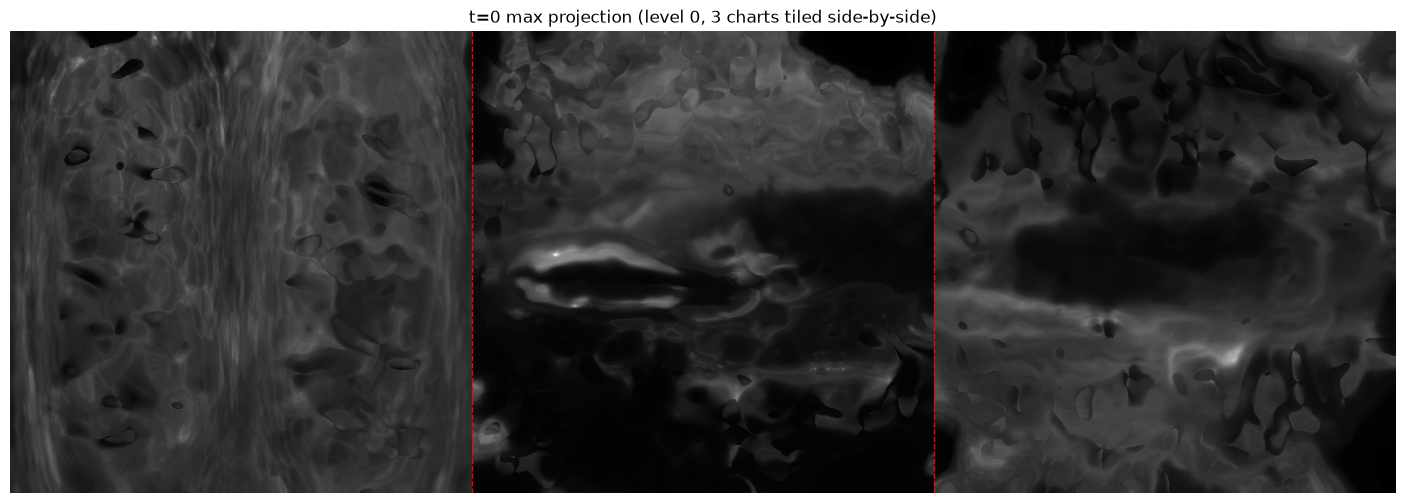

In [8]:
with timed("t=0 read level-0 intensity volume"):
    vol0 = ds.read_volume(t=T, level=INTENSITY_LEVEL)

print(f"vol0: shape={vol0.shape}, dtype={vol0.dtype}, {vol0.nbytes / 1e9:.2f} GB")

with timed("t=0 project_to_uv_along_normals (level 0)"):
    result = p0.project_to_uv_along_normals(
        vol0, offsets=np.linspace(5, -20, 30), uv_res=UV_RES, return_maps=True)

# NUM_CHARTS>1 makes project_to_uv_along_normals return one (layers, H, W) array per
# chart instead of a single array. Tile them side-by-side along the width axis --
# chart k -> columns [k*UV_RES, (k+1)*UV_RES) -- the same convention
# ProjectedFrame.from_parameterizer uses (seamless/pipeline.py:676-680), so every
# chart's progression renders in one combined image instead of crashing or only
# showing one chart.
if isinstance(result[0], list):
    multilayers, xyz_vox_list, xyz_norm_list = result
    multilayer0 = np.concatenate(multilayers, axis=2)    # (L, H, K*W)
    xyz_vox0    = np.concatenate(xyz_vox_list, axis=1)   # (H, K*W, 3)
    xyz_norm0   = np.concatenate(xyz_norm_list, axis=1)  # (H, K*W, 3)
else:
    multilayer0, xyz_vox0, xyz_norm0 = result

max_proj0 = multilayer0.max(axis=0)
print(f"multilayer: {multilayer0.shape}  max_projection: {max_proj0.shape}")

fig, ax = plt.subplots(figsize=(6 * NUM_CHARTS, 6))
ax.imshow(max_proj0, cmap="gray")
ax.set_title(f"t=0 max projection (level 0, {NUM_CHARTS} charts tiled side-by-side)")
for k in range(1, NUM_CHARTS):
    ax.axvline(k * UV_RES, color="red", linewidth=1, linestyle="--")
ax.axis("off")
plt.show()

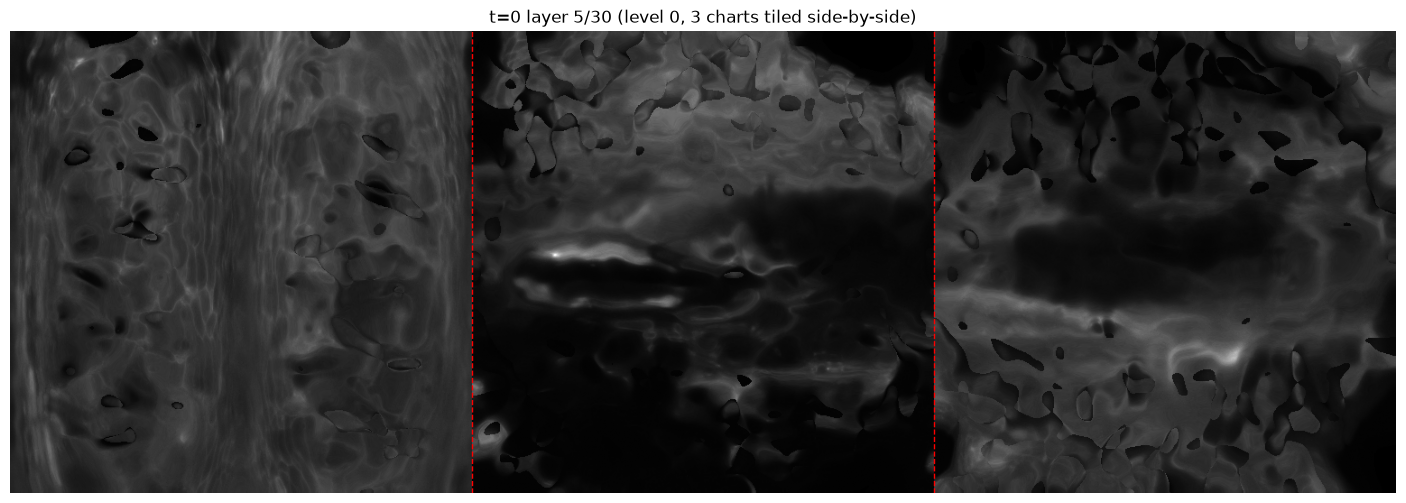

In [9]:
fig, ax = plt.subplots(figsize=(6 * NUM_CHARTS, 6))
ax.imshow(multilayer0[25], cmap="gray")
ax.set_title(f"t=0 layer 5/30 (level 0, {NUM_CHARTS} charts tiled side-by-side)")
for k in range(1, NUM_CHARTS):
    ax.axvline(k * UV_RES, color="red", linewidth=1, linestyle="--")
ax.axis("off")
plt.show()